# Electricity Theft Detection

**Track:** Energy Systems — Predictive Maintenance / Anomaly Detection
**Advanced Topics:** XAI (SHAP) + Adversarial Robustness (FGSM)
**Dataset:** UCI Electricity Load Diagrams + Synthetic Theft Labels

In [1]:
import importlib.util
import os
import subprocess
import sys

NUM_CPUS_REQUESTED = 32
THREADS_STR = str(NUM_CPUS_REQUESTED)

# Must be set before NumPy/PyTorch imports in later cells.
for env_var in [
    'OMP_NUM_THREADS',
    'MKL_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'NUMEXPR_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'BLIS_NUM_THREADS',
]:
    os.environ[env_var] = THREADS_STR

os.environ['OMP_DYNAMIC'] = 'FALSE'
os.environ['MKL_DYNAMIC'] = 'FALSE'
os.environ['KMP_AFFINITY'] = 'granularity=fine,compact,1,0'

PACKAGE_MAP = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'torch': 'torch',
    'shap': 'shap',
    'lime': 'lime',
    'kagglehub': 'kagglehub',
}

missing = [pip_name for module_name, pip_name in PACKAGE_MAP.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print(f'Installing missing packages: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('All required packages already available in this kernel.')

print(f'Thread env configured to {THREADS_STR} for OpenMP/BLAS backends.')
print('Dependency check complete.')

Installing missing packages: ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'torch', 'shap', 'lime', 'kagglehub']
Thread env configured to 32 for OpenMP/BLAS backends.
Dependency check complete.


In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss
    )
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_CPUS_REQUESTED = int(os.environ.get('OMP_NUM_THREADS', '32'))
AVAILABLE_CPUS = os.cpu_count() or 1
CPU_THREADS = min(NUM_CPUS_REQUESTED, AVAILABLE_CPUS)
torch.set_num_threads(CPU_THREADS)
if hasattr(torch, 'set_num_interop_threads'):
    try:
        torch.set_num_interop_threads(CPU_THREADS)
    except RuntimeError:
        pass  # Already initialized in this kernel session.

USE_GPU = torch.cuda.is_available()
USE_AMP = USE_GPU
device = torch.device('cuda' if USE_GPU else 'cpu')

if USE_GPU:
    torch.backends.cudnn.benchmark = True
    BATCH_SIZE = 16384
    EVAL_BATCH_SIZE = 16384
    NUM_WORKERS = min(8, AVAILABLE_CPUS)
else:
    torch.backends.mkldnn.enabled = True
    BATCH_SIZE = 8192
    EVAL_BATCH_SIZE = 8192
    NUM_WORKERS = 0

PIN_MEMORY = USE_GPU

print(f'PyTorch: {torch.__version__}')
print(f'SHAP: {shap.__version__}')
print(f'Device: {device}')
if USE_GPU:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
print(f'CPU threads configured: {CPU_THREADS}/{AVAILABLE_CPUS}')
print(f'torch.get_num_threads(): {torch.get_num_threads()}')
print(f'torch.get_num_interop_threads(): {torch.get_num_interop_threads()}')
print(f'Batch sizes -> train: {BATCH_SIZE}, eval: {EVAL_BATCH_SIZE}')
print(f'DataLoader workers: {NUM_WORKERS}')
print(f'Automatic mixed precision: {USE_AMP}')
print('Torch parallel info:')
print(torch.__config__.parallel_info())

/opt/conda/envs/colab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu130
SHAP: 0.51.0
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 23.56 GB
CPU threads configured: 32/32
torch.get_num_threads(): 32
torch.get_num_interop_threads(): 32
Batch sizes -> train: 16384, eval: 16384
DataLoader workers: 8
Automatic mixed precision: True
Torch parallel info:
ATen/Parallel:
	at::get_num_threads() : 32
	at::get_num_interop_threads() : 32
OpenMP 201511 (a.k.a. OpenMP 4.5)
	omp_get_max_threads() : 32
Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
	mkl_get_max_threads() : 32
Intel(R) MKL-DNN v3.10.2 (Git Hash f1d471933dc852f956fd05389f9313c7148783d5)
std::thread::hardware_concurrency() : 32
Environment variables:
	OMP_NUM_THREADS : 32
	MKL_NUM_THREADS : 32
ATen parallel backend: OpenMP



## Data Acquisition and Exploratory Analysis

This section downloads the dataset, selects one meter stream, and performs quick visualization and quality checks before modeling.

In [3]:
import glob
import os

import kagglehub

def read_tabular_file(file_path):
    """Read CSV/TXT with simple delimiter fallback."""
    try:
        return pd.read_csv(file_path, sep=None, engine='python')
    except Exception:
        pass
    try:
        return pd.read_csv(file_path, sep=';')
    except Exception:
        return pd.read_csv(file_path)

# Download dataset
path = kagglehub.dataset_download('eduardojst10/electricityloaddiagrams20112014')
print(f'Dataset downloaded to: {path}')

# Candidate files: prefer meter CSV, then any CSV, then TXT
meter_candidates = glob.glob(os.path.join(path, '**', 'Meter_001.csv'), recursive=True)
csv_candidates = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
txt_candidates = glob.glob(os.path.join(path, '**', '*.txt'), recursive=True)

if meter_candidates:
    data_file = meter_candidates[0]
elif csv_candidates:
    data_file = csv_candidates[0]
elif txt_candidates:
    data_file = txt_candidates[0]
else:
    raise FileNotFoundError('No CSV/TXT data file found in downloaded dataset.')

df_raw = read_tabular_file(data_file)
print(f'Using file: {data_file}')
print(f'Raw shape: {df_raw.shape}')

# Select a numeric meter column with real signal (highest std, non-constant)
column_stats = []
for col in df_raw.columns:
    series = pd.to_numeric(df_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    valid = series.notna().sum()
    std = float(series.std(skipna=True)) if valid > 0 else 0.0
    column_stats.append((col, valid, std))

# Prefer columns with meaningful variance
varying_cols = [item for item in column_stats if np.isfinite(item[2]) and item[2] > 1e-8 and item[1] > 0]
if varying_cols:
    best_col = max(varying_cols, key=lambda x: (x[2], x[1]))[0]
else:
    best_col = max(column_stats, key=lambda x: x[1])[0]

load_series = pd.to_numeric(
    df_raw[best_col].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
    ).ffill().bfill()

df = pd.DataFrame({'load': load_series.astype(np.float32)})
print(f'Selected load column: {best_col}')
print(f'Prepared shape: {df.shape}')
print(df.head())
print(df.info())
print(f'Load std: {df["load"].std():.6f}')

Dataset downloaded to: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1
Using file: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv
Raw shape: (140256, 371)
Selected load column: MT_362
Prepared shape: (140256, 1)
   load
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0
<class 'pandas.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   load    140256 non-null  float32
dtypes: float32(1)
memory usage: 548.0 KB
None
Load std: 9681.457031


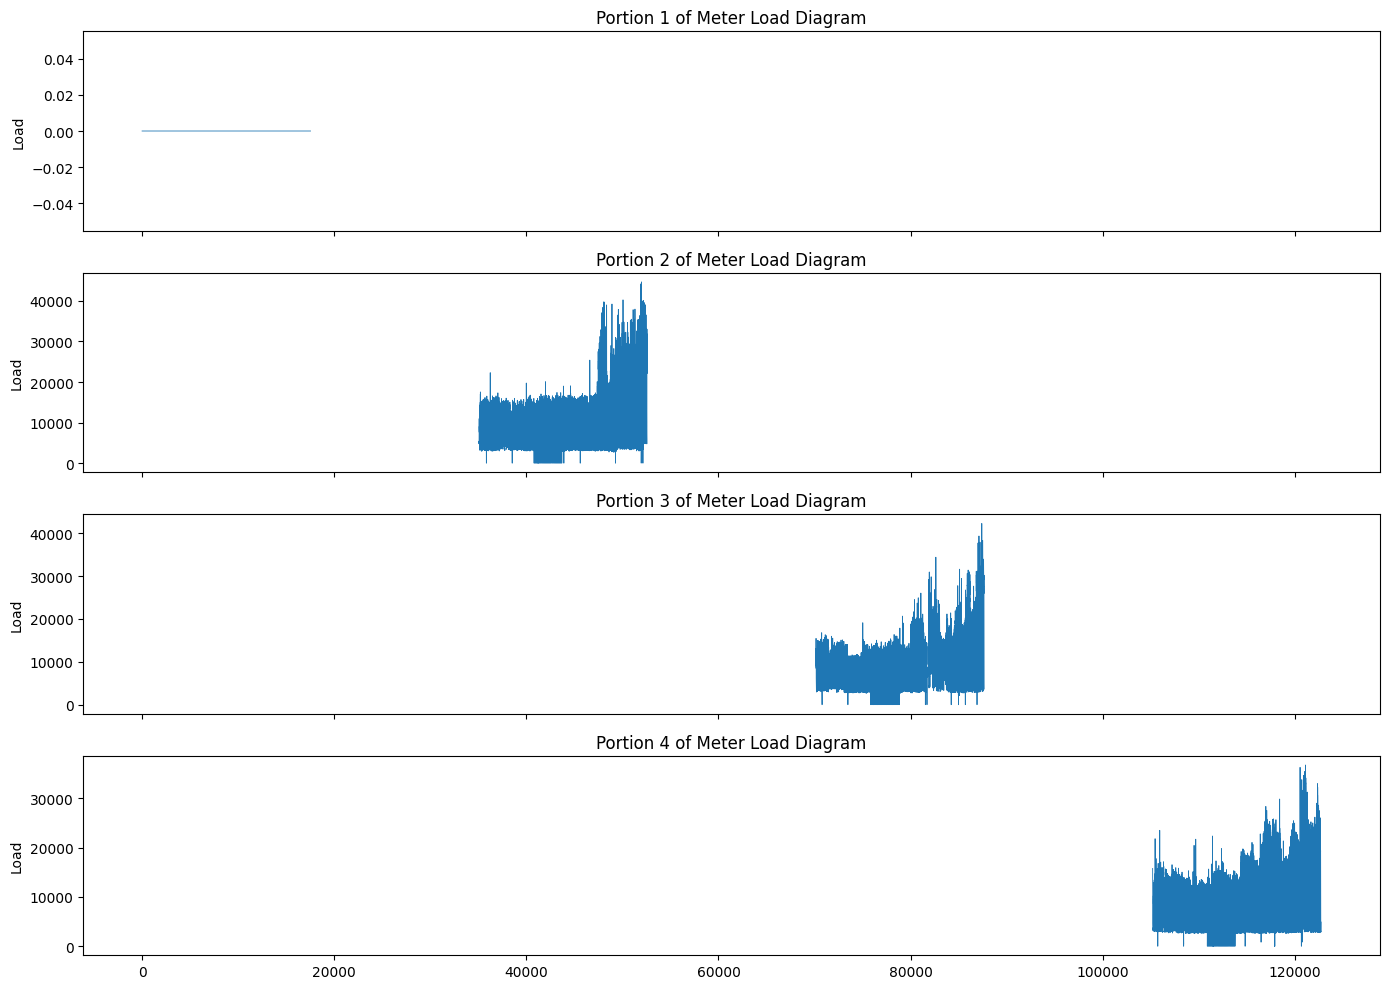

                load
count  140256.000000
mean     9390.235352
std      9681.457031
min         0.000000
25%         0.000000
50%      6025.000000
75%     13700.000000
max     48200.000000
Missing values per column:
Series([], dtype: int64)


In [4]:
# Plot load data for the selected meter
load_values = df['load'].astype(float).values

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i in range(4):
    start = i * len(load_values) // 4
    end = start + len(load_values) // 8
    axes[i].plot(range(start, end), load_values[start:end], linewidth=0.6)
    axes[i].set_title(f'Portion {i + 1} of Meter Load Diagram')
    axes[i].set_ylabel('Load')

plt.tight_layout()
plt.savefig('baseline_load_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.describe())

missing = df.isnull().sum()
print(f'Missing values per column:\n{missing[missing > 0]}')

In [5]:
def create_time_windows(data, window_size=24):
    """
    Convert a 1D load series into sliding windows and hourly cyclical features.
    Returns:
        load_windows: (n_samples, window_size)
        hour_sin:     (n_samples, window_size)
    """
    data = np.asarray(data, dtype=np.float32)
    load_windows = []
    hour_windows = []

    base_hours = np.arange(window_size) % 24
    hour_sin_template = np.sin(2 * np.pi * base_hours / 24).astype(np.float32)

    for i in range(0, len(data) - window_size + 1):
        window = data[i:i + window_size]
        load_windows.append(window)
        hour_windows.append(hour_sin_template)

    load_windows = np.stack(load_windows)
    hour_windows = np.stack(hour_windows)
    return load_windows, hour_windows

raw_series = df['load'].ffill().bfill().values
X_load, X_hour = create_time_windows(raw_series, window_size=24)
print(f'Windowed shape (load): {X_load.shape}')
print(f'Windowed shape (hour_sin): {X_hour.shape}')

Windowed shape (load): (140233, 24)
Windowed shape (hour_sin): (140233, 24)


In [6]:
def generate_synthetic_labels(X_load, n_anomalies=0.15, seed=42):
    """
    Generate synthetic electricity theft labels by injecting anomalies into normal load data.
    Three types of theft patterns:
    - Sudden drops (bypassed meter): reduce consumption 50-80%
    - Unusual spikes (illegal connections): add 2-3x normal baseline
    - Flat-line periods (tampered reading): set to zero or constant

    Returns corrupted load array and binary labels.
    """
    np.random.seed(seed)
    n_samples = len(X_load)
    labels = np.zeros(n_samples, dtype=int)
    X_corrupted = X_load.copy()

    n_anom = int(n_samples * n_anomalies)
    anom_indices = np.random.choice(n_samples, n_anom, replace=False)

    anomaly_types = np.random.randint(0, 3, n_anom)

    for idx, atype in zip(anom_indices, anomaly_types):
        if atype == 0:  # Sudden drop (bypassed meter)
            reduction = np.random.uniform(0.5, 0.8)
            X_corrupted[idx] *= reduction
            labels[idx] = 1
        elif atype == 1:  # Unusual spike (illegal connection)
            multiplier = np.random.uniform(2.0, 3.0)
            baseline_mean = X_load[idx].mean()
            X_corrupted[idx] += baseline_mean * (multiplier - 1)
            labels[idx] = 1
        else:  # Flat-line (tampered reading)
            constant_val = np.random.uniform(0, X_load[idx].max() * 0.1)
            X_corrupted[idx] = constant_val
            labels[idx] = 1

    return X_corrupted, labels

X_thief, y_labels = generate_synthetic_labels(X_load, n_anomalies=0.15)
print(f'Anomaly rate: {y_labels.mean():.2%}')

Anomaly rate: 15.00%


In [7]:
# Build sequence features: each timestep has [load_value, hour_sin]
X_seq = np.stack([X_thief, X_hour], axis=-1).astype(np.float32)  # (n_samples, 24, 2)

# Temporal train/test split (do NOT shuffle)
split_idx = int(len(X_seq) * 0.8)
X_train_raw = X_seq[:split_idx]
X_test_raw = X_seq[split_idx:]
y_train = y_labels[:split_idx]
y_test = y_labels[split_idx:]

# Use full data on GPU, compact subset on CPU for practical runtime.
if USE_GPU:
    MAX_TRAIN_SAMPLES = len(X_train_raw)
    MAX_TEST_SAMPLES = len(X_test_raw)
else:
    MAX_TRAIN_SAMPLES = 60000
    MAX_TEST_SAMPLES = 15000

if len(X_train_raw) > MAX_TRAIN_SAMPLES:
    X_train_raw = X_train_raw[-MAX_TRAIN_SAMPLES:]
    y_train = y_train[-MAX_TRAIN_SAMPLES:]
if len(X_test_raw) > MAX_TEST_SAMPLES:
    X_test_raw = X_test_raw[:MAX_TEST_SAMPLES]
    y_test = y_test[:MAX_TEST_SAMPLES]

# Normalize per feature channel using train statistics only
mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
    )

print(f'X_train shape: {X_train_t.shape}')
print(f'X_test shape:  {X_test_t.shape}')
print(f'Train anomalies: {y_train.sum()} / {len(y_train)}')
print(f'Test anomalies:  {y_test.sum()} / {len(y_test)}')

X_train shape: torch.Size([112186, 24, 2])
X_test shape:  torch.Size([28047, 24, 2])
Train anomalies: 16866 / 112186
Test anomalies:  4168 / 28047


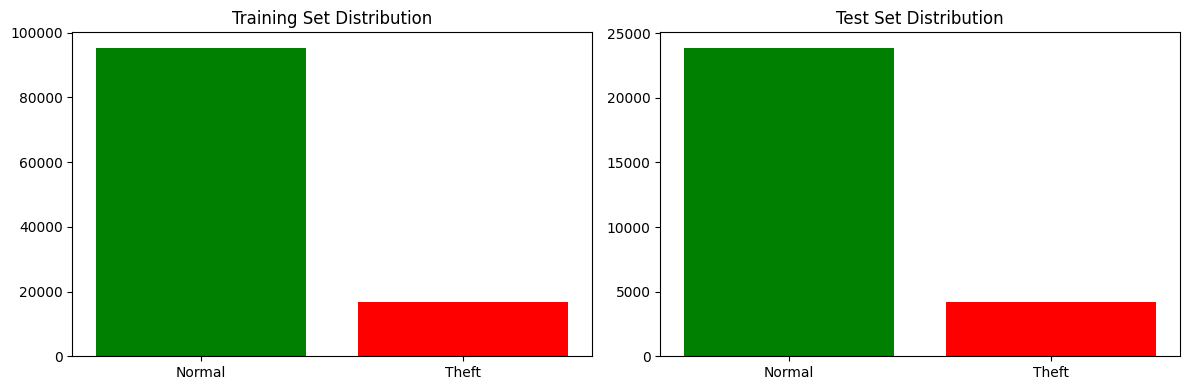

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_normal = int((y_train == 0).sum())
train_theft = int((y_train == 1).sum())
test_normal = int((y_test == 0).sum())
test_theft = int((y_test == 1).sum())

axes[0].bar(['Normal', 'Theft'], [train_normal, train_theft], color=['green', 'red'])
axes[0].set_title('Training Set Distribution')

axes[1].bar(['Normal', 'Theft'], [test_normal, test_theft], color=['green', 'red'])
axes[1].set_title('Test Set Distribution')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
class TheftDetectionLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        logits = self.classifier(h_n[-1])
        return logits.squeeze(-1)

model = TheftDetectionLSTM(input_size=2, hidden_size=64, num_layers=2).to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')

TheftDetectionLSTM(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 52801


Epoch [1/12], Loss: 1.1782
Epoch [2/12], Loss: 1.1744
Epoch [3/12], Loss: 1.1659
Epoch [4/12], Loss: 1.1439
Epoch [5/12], Loss: 1.1190
Epoch [6/12], Loss: 1.1054
Epoch [7/12], Loss: 1.0945
Epoch [8/12], Loss: 1.0831
Epoch [9/12], Loss: 1.0746
Epoch [10/12], Loss: 1.0730
Epoch [11/12], Loss: 1.0668
Epoch [12/12], Loss: 1.0643


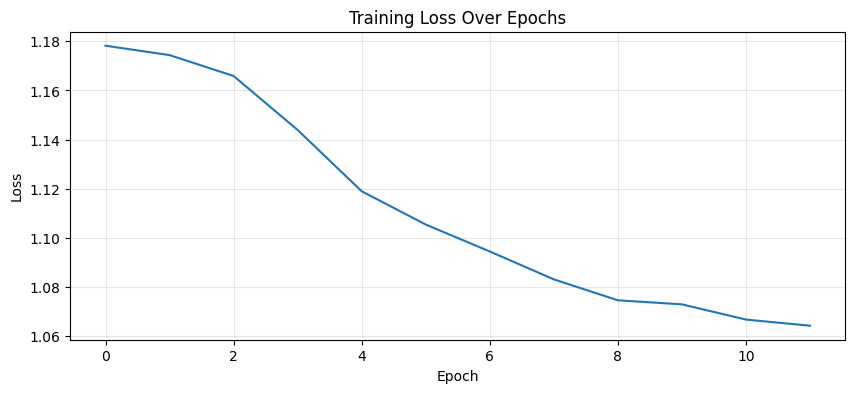

Model saved to theft_detection_lstm.pth


In [10]:
# Compute class weights for imbalanced data
pos_weight_value = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

epochs = 12
patience = 4
min_delta = 1e-4
best_loss = float('inf')
epochs_without_improvement = 0
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
        batch_y = batch_y.float().to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            logits = model(batch_X)
            loss = criterion(logits, batch_y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / max(n_batches, 1)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}')

    if avg_loss + min_delta < best_loss:
        best_loss = avg_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'theft_detection_lstm.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f'Early stopping at epoch {epoch + 1} (best loss: {best_loss:.4f})')
            break

model.load_state_dict(torch.load('theft_detection_lstm.pth', map_location=device))
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model saved to theft_detection_lstm.pth')

In [11]:
# Evaluate on test set
model.eval()
all_preds = []
all_probs = []
all_logits = []

with torch.no_grad():
    for i in range(0, len(X_test_t), EVAL_BATCH_SIZE):
        batch = X_test_t[i:i + EVAL_BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            logits = model(batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        all_logits.extend(logits.float().cpu().numpy())
        all_probs.extend(probs.float().cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_logits = np.array(all_logits)
y_true = y_test_t.numpy()

precision, recall, f1, _ = precision_recall_fscore_support(y_true, all_preds, average='binary')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'\nClassification Report:\n{classification_report(y_true, all_preds, target_names=["Normal", "Theft"])}')

Precision: 0.3081
Recall:    0.5909
F1-Score:  0.4050

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.77      0.84     23879
       Theft       0.31      0.59      0.41      4168

    accuracy                           0.74     28047
   macro avg       0.61      0.68      0.62     28047
weighted avg       0.82      0.74      0.77     28047



## Explainability Analysis (SHAP)

After baseline evaluation, this section inspects which time steps and cyclical features influence model decisions.

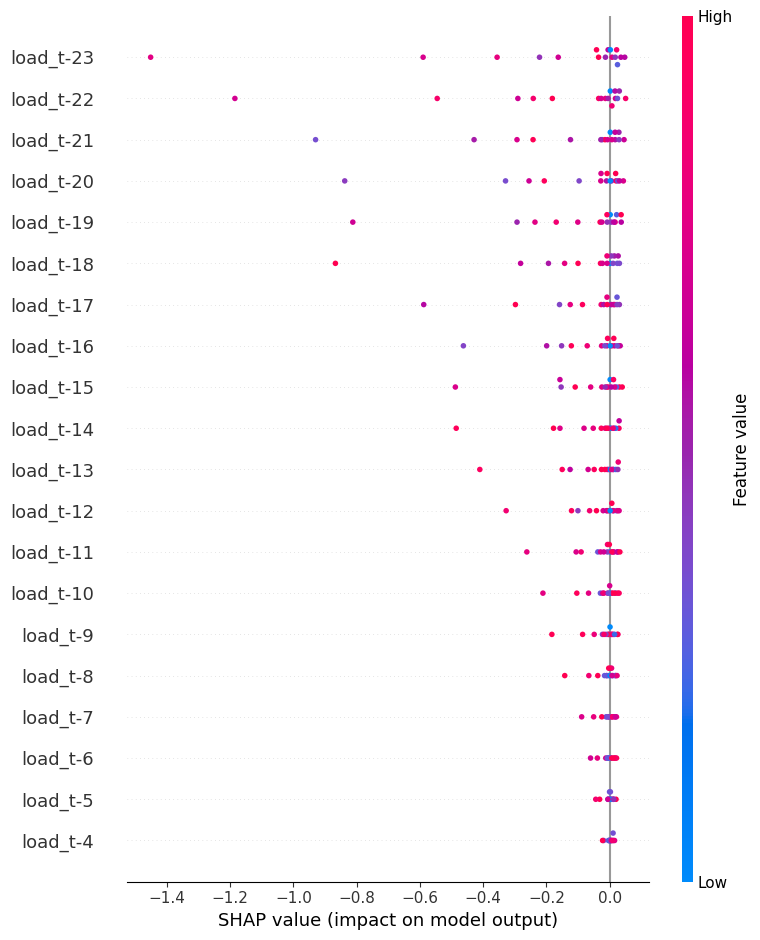

SHAP computed on CPU with background=32, test_samples=16, nsamples=20
Top 10 features by mean |SHAP|:
 1. load_t-23: 0.18956
 2. load_t-22: 0.16707
 3. load_t-21: 0.13986
 4. load_t-20: 0.12157
 5. load_t-19: 0.11335
 6. load_t-18: 0.11043
 7. load_t-17: 0.08932
 8. load_t-16: 0.07391
 9. load_t-15: 0.07172
10. load_t-14: 0.06980


In [13]:
# Explain model predictions with SHAP (GradientExplainer for PyTorch sequence model)
model.eval()

class SHAPWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x).unsqueeze(-1)

# Run SHAP on CPU to avoid cuDNN RNN backward limitations on GPU.
shap_device = torch.device('cpu')
model_for_shap = TheftDetectionLSTM(input_size=2, hidden_size=64, num_layers=2).to(shap_device)
model_for_shap.load_state_dict(model.state_dict())
model_for_shap.eval()
shap_model = SHAPWrapper(model_for_shap).to(shap_device)
shap_model.eval()

# Keep SHAP budget small so notebook remains fully runnable.
background_size = min(32, len(X_train_t))
test_size = min(16, len(X_test_t))
shap_nsamples = 20

background = X_train_t[:background_size].to(shap_device)
test_samples = X_test_t[:test_size].to(shap_device)

explainer = shap.GradientExplainer(shap_model, background)
raw_shap_values = explainer.shap_values(test_samples, nsamples=shap_nsamples)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[0]
else:
    shap_values = raw_shap_values

if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

shap_values = np.asarray(shap_values)
if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

test_np = test_samples.detach().cpu().numpy()

# Flatten [time, feature] so summary_plot can visualize all inputs
shap_flat = shap_values.reshape(shap_values.shape[0], -1)
test_flat = test_np.reshape(test_np.shape[0], -1)

feature_names = []
for t in range(test_np.shape[1]):
    feature_names.extend([f'load_t-{test_np.shape[1]-1-t}', f'hour_sin_t-{test_np.shape[1]-1-t}'])

mean_abs_shap = np.mean(np.abs(shap_flat), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_flat, test_flat, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'SHAP computed on CPU with background={background_size}, test_samples={test_size}, nsamples={shap_nsamples}')
print('Top 10 features by mean |SHAP|:')
for rank in range(10):
    idx = sorted_idx[rank]
    print(f'{rank+1:>2}. {feature_names[idx]}: {mean_abs_shap[idx]:.5f}')

In [ ]:
# Local SHAP explanations for selected samples (within SHAP test subset only)
subset_true = y_true[:test_size]
subset_preds = all_preds[:test_size]

candidate_theft = np.where(subset_preds == 1)[0]
candidate_normal = np.where(subset_preds == 0)[0]

selected_indices = []
if len(candidate_theft) > 0:
    selected_indices.append(int(candidate_theft[0]))
if len(candidate_theft) > 1:
    selected_indices.append(int(candidate_theft[1]))
if len(candidate_normal) > 0:
    selected_indices.append(int(candidate_normal[0]))

if not selected_indices:
    selected_indices = [0]

for plot_id, idx in enumerate(selected_indices):
    sample_shap = shap_flat[idx]
    top_local = np.argsort(np.abs(sample_shap))[::-1][:10]

    plt.figure(figsize=(10, 4))
    plt.barh([feature_names[i] for i in top_local][::-1], sample_shap[top_local][::-1])
    plt.title(
        f'Local SHAP explanation for sample {idx} | '
        f'True: {"THEFT" if subset_true[idx] == 1 else "NORMAL"} | '
        f'Pred: {"THEFT" if subset_preds[idx] == 1 else "NORMAL"}'
    )
    plt.xlabel('SHAP value contribution')
    plt.tight_layout()
    plt.savefig(f'shap_local_bar_{plot_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Adversarial Robustness Testing (FGSM)

This section measures how performance changes under bounded perturbations and visualizes robustness trends across epsilon levels.

In [ ]:
# FGSM adversarial attack helper
attack_criterion = nn.BCEWithLogitsLoss()
x_clip_min = float(X_train_t.min().item())
x_clip_max = float(X_train_t.max().item())

def fgsm_attack(model, x_batch, y_batch, epsilon=0.05):
    """Generate FGSM adversarial samples for a batch."""
    x_adv = x_batch.clone().detach().to(device)
    y_adv = y_batch.clone().detach().float().to(device)

    x_adv.requires_grad_(True)
    logits = model(x_adv)
    loss = attack_criterion(logits, y_adv)

    model.zero_grad(set_to_none=True)
    loss.backward()

    perturbed = x_adv + epsilon * x_adv.grad.sign()
    perturbed = torch.clamp(perturbed, x_clip_min, x_clip_max)
    return perturbed.detach()

In [ ]:
# Adversarial robustness test across epsilon values
epsilon_values = [0.0, 0.01, 0.05, 0.1]
robustness_results = {}

y_true = y_test_t.numpy()

for eps in epsilon_values:
    model.eval()
    adv_preds = []
    adv_probs = []

    for i in range(0, len(X_test_t), EVAL_BATCH_SIZE):
        batch_x = X_test_t[i:i + EVAL_BATCH_SIZE].to(device)
        batch_y = y_test_t[i:i + EVAL_BATCH_SIZE].to(device)

        if eps > 0:
            adv_x = fgsm_attack(model, batch_x, batch_y, epsilon=eps)
        else:
            adv_x = batch_x

        with torch.no_grad():
            adv_logits = model(adv_x)
            probs = torch.sigmoid(adv_logits)
            preds = (probs >= 0.5).long()

        adv_probs.extend(probs.cpu().numpy())
        adv_preds.extend(preds.cpu().numpy())

    adv_preds = np.array(adv_preds)
    adv_probs = np.array(adv_probs)

    precision_a = precision_score(y_true, adv_preds, zero_division=0)
    recall_a = recall_score(y_true, adv_preds, zero_division=0)
    f1_a = f1_score(y_true, adv_preds, zero_division=0)
    fn = int(np.logical_and(y_true == 1, adv_preds == 0).sum())
    tp = int(np.logical_and(y_true == 1, adv_preds == 1).sum())
    fnr_a = fn / max(fn + tp, 1)

    robustness_results[eps] = {
        'precision': float(precision_a),
        'recall': float(recall_a),
        'f1': float(f1_a),
        'fnr': float(fnr_a),
    }

print('\nAdversarial Robustness Results:')
print(f'{"Epsilon":<10} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"FNR":<10}')
print('-' * 58)
for eps, metrics in robustness_results.items():
    print(
        f'{eps:<10.2f} {metrics["precision"]:<12.4f} '
        f'{metrics["recall"]:<12.4f} {metrics["f1"]:<12.4f} {metrics["fnr"]:<10.4f}'
    )

In [ ]:
eps_list = list(robustness_results.keys())
precisions = [robustness_results[e]['precision'] for e in eps_list]
recalls = [robustness_results[e]['recall'] for e in eps_list]
f1s = [robustness_results[e]['f1'] for e in eps_list]

plt.figure(figsize=(10, 5))
plt.plot(eps_list, precisions, 'o-', label='Precision', color='blue')
plt.plot(eps_list, recalls, 's-', label='Recall', color='green')
plt.plot(eps_list, f1s, '^-', label='F1-Score', color='red')
plt.xlabel('Epsilon (Perturbation Magnitude)')
plt.ylabel('Metric Value')
plt.title('Model Robustness Under FGSM Attacks')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('adversarial_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Precision-Recall curve and confusion matrix
precisions_curve, recalls_curve, _ = precision_recall_curve(y_true, all_probs)
pr_auc = auc(recalls_curve, precisions_curve)

plt.figure(figsize=(8, 6))
plt.plot(recalls_curve, precisions_curve, label=f'PR-AUC = {pr_auc:.4f}', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(y_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Theft'],
    yticklabels=['Normal', 'Theft']
    )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confusion Matrix:\n{cm}')

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)

print('\n1. Baseline Model Performance:')
print(f'   Precision: {robustness_results[0.0]["precision"]:.4f}')
print(f'   Recall:    {robustness_results[0.0]["recall"]:.4f}')
print(f'   F1-Score:  {robustness_results[0.0]["f1"]:.4f}')
print(f'   FNR:       {robustness_results[0.0]["fnr"]:.4f}')

print('\n2. Adversarial Robustness (F1 Drop):')
for eps in [0.01, 0.05, 0.10]:
    drop = robustness_results[0.0]['f1'] - robustness_results[eps]['f1']
    print(f'   Epsilon={eps:.2f}: F1-Drop = {drop:.4f}')

print('\n3. Explainability Outputs:')
print('   SHAP summary: shap_summary.png')
print('   Local SHAP plots: shap_local_bar_*.png')
print('=' * 60)

In [ ]:
import json

# Export metrics to JSON for report population
baseline = robustness_results.get(0.0, {})

results = {
    'baseline_precision': baseline.get('precision'),
    'baseline_recall': baseline.get('recall'),
    'baseline_f1': baseline.get('f1'),
    'pr_auc': float(pr_auc) if 'pr_auc' in globals() else None,
    'roc_auc': float(roc_auc) if 'roc_auc' in globals() else None,
    'robustness_under_attack': {str(k): v for k, v in robustness_results.items()},
    'confusion_matrix': cm.tolist() if 'cm' in globals() else None,
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print('\nResults exported to results.json')